# 01 - Data Check: NDX Price Data & News Headlines

Author: Shivli | Task: Data validation (Stage 1)

Checks performed:
- Price data: row count, date range, missing values, duplicate dates, columns
- News data: row count, date range, duplicate headlines, missing dates, headlines-per-day
- Plots: close price, daily returns, headlines-per-day


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)


## 1. Price data checks (`data/raw/stock_price.csv`)

In [2]:
# The raw CSV has 2 extra header rows from yfinance's multi-index columns
# (Ticker row, blank Date row) before the actual data starts.
price_df = pd.read_csv('../data/raw/stock_price.csv', skiprows=2)
price_df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
price_df['Date'] = pd.to_datetime(price_df['Date'])
for col in ['Close', 'High', 'Low', 'Open', 'Volume']:
    price_df[col] = pd.to_numeric(price_df[col], errors='coerce')

print('Rows:', len(price_df))
print('Date range:', price_df['Date'].min().date(), 'to', price_df['Date'].max().date())
print('Columns:', list(price_df.columns))
price_df.head()


Rows: 480
Date range: 2020-10-02 to 2022-09-29
Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


,Date,Close,High,Low,Open,Volume
0,2020-10-02,11255.690430,11255.690430,11255.690430,11255.690430,0
1,2020-10-05,11509.059570,11509.059570,11509.059570,11509.059570,0
2,2020-10-06,11291.269531,11291.269531,11291.269531,11291.269531,0
3,2020-10-07,11503.190430,11503.190430,11503.190430,11503.190430,0
4,2020-10-08,11550.940430,11550.940430,11550.940430,11550.940430,0


In [3]:
missing = price_df.isna().sum()
dup_dates = price_df['Date'].duplicated().sum()
print('Missing values per column:')
print(missing)
print('\nDuplicate dates:', dup_dates)


Missing values per column:
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Duplicate dates: 0


In [4]:
# Data quality check: are OHLC columns actually distinct, and is Volume populated?
ohlc_identical = ((price_df['Open'] == price_df['Close']) &
                   (price_df['High'] == price_df['Close']) &
                   (price_df['Low'] == price_df['Close'])).mean()
zero_volume_pct = (price_df['Volume'] == 0).mean()

print(f'Rows where Open==High==Low==Close: {ohlc_identical:.1%}')
print(f'Rows where Volume == 0: {zero_volume_pct:.1%}')


Rows where Open==High==Low==Close: 100.0%
Rows where Volume == 0: 100.0%


Open, High, Low and Close are identical on effectively every row, and Volume is 0 throughout. So the current stock_price.csv only really carries a single price series (Close), not genuine OHLCV data. This looks like a bad yfinance download (probably a column-flattening issue on the multi-index columns), and OHLC-based features would be meaningless until it's re-downloaded properly.

In [5]:
# Are there any missing trading days? Compare against a business-day calendar.
full_bdays = pd.bdate_range(price_df['Date'].min(), price_df['Date'].max())
missing_bdays = full_bdays.difference(price_df['Date'])
print('Business days in range:', len(full_bdays))
print('Business days present in data:', price_df['Date'].nunique())
print('Missing business days (may include market holidays):', len(missing_bdays))


Business days in range: 520
Business days present in data: 480
Missing business days (may include market holidays): 40


## 2. News data checks (`data/raw/news.csv`)

In [6]:
news_df = pd.read_csv('../data/raw/news.csv')
news_df['Date'] = pd.to_datetime(news_df['Date'])
headline_cols = [c for c in news_df.columns if c.startswith('News')]

print('Rows (days):', len(news_df))
print('Date range:', news_df['Date'].min().date(), 'to', news_df['Date'].max().date())
print('Headline columns:', headline_cols)
news_df.head(2)


Rows (days): 730
Date range: 2020-10-01 to 2022-09-30
Headline columns: ['News 1', 'News 2', 'News 3', 'News 4', 'News 5', 'News 6', 'News 7', 'News 8', 'News 9', 'News 10']


,Date,News 1,News 2,News 3,News 4,News 5,News 6,News 7,News 8,News 9,News 10
0,2020-10-01,A standoff over further federal aid and concer...,With few people traveling and lawmakers deadlo...,After Tuesday’s debacle right-wing activists a...,BitMEX made itself a haven for hackers and ill...,Banks collected at least $13 billion in fees o...,Many of the posts on the pages include false o...,The unemployment insurance system — the main a...,House Democrats on Thursday pushed through a $...,Shares in the Swedish retailer H&M rose more t...,Pandemic programs have lowered the barriers to...
1,2020-10-02,Tesla reported record deliveries in the third ...,Payrolls grew last month but permanent layoffs...,The network is taking precautions after Lachla...,The anchor who sat about 12 feet from Presiden...,Trump administration officials claim the Chine...,Stories about Trump’s taxes the Proud Boys and...,Trump administration officials on Friday put a...,As the president clashes with the courts some ...,Overnight hundreds of tweets were posted casti...,Many people who lost their jobs in the first w...


In [7]:
dup_dates_news = news_df['Date'].duplicated().sum()
missing_dates_news = news_df['Date'].isna().sum()

# Count actual non-empty headlines per day
def count_headlines(row):
    vals = [row[c] for c in headline_cols]
    return sum(1 for v in vals if pd.notna(v) and str(v).strip() not in ('', '0'))

news_df['headline_count'] = news_df.apply(count_headlines, axis=1)

print('Duplicate dates:', dup_dates_news)
print('Missing dates:', missing_dates_news)
print('Headlines per day - mean:', news_df['headline_count'].mean().round(2),
      'min:', news_df['headline_count'].min(),
      'max:', news_df['headline_count'].max())


Duplicate dates: 0
Missing dates: 0
Headlines per day - mean: 7.66 min: 0 max: 10


In [8]:
# Duplicate headline text across the whole dataset (not just within a day).
# '0' is used in this file as a placeholder for an empty headline slot, so it
# is excluded here the same way it is excluded when counting real headlines.
all_headlines = pd.concat([news_df[c] for c in headline_cols]).dropna()
all_headlines = all_headlines[all_headlines.astype(str).str.strip().ne('')]
all_headlines = all_headlines[all_headlines.astype(str) != '0']

placeholder_count = (pd.concat([news_df[c] for c in headline_cols]).astype(str) == '0').sum()
dup_counts = all_headlines.value_counts()
real_duplicates = dup_counts[dup_counts > 1]

print('Total real headline cells (excluding \'0\' placeholders):', len(all_headlines))
print('\'0\' placeholder cells (empty headline slots):', placeholder_count)
print('Distinct headlines that repeat:', len(real_duplicates))
print('Total duplicate rows:', all_headlines.duplicated().sum())
print('\nTop repeated headlines:')
print(real_duplicates.head(5))


Total real headline cells (excluding '0' placeholders): 5592
'0' placeholder cells (empty headline slots): 1700
Distinct headlines that repeat: 10
Total duplicate rows: 61

Top repeated headlines:
Recent commercial real estate transactions in New York.                                                                                    50
Crypto is a lot of things – including terribly explained. We’re here to clear things up.                                                    5
The incumbent governor and some of his allies argued without showing any evidence that there were voting irregularities and fraud.          2
The tweet from Dr. Scott Atlas one of the president’s top science advisers was debunked by many experts and deleted by Twitter.             2
Dubious stories about George Soros Ukraine and vote-by-mail have spread widely on social media this year and we may just be warming up.     2
Name: count, dtype: int64


In [9]:
# Do price and news dates line up?
price_dates = set(price_df['Date'])
news_dates = set(news_df['Date'])

print('Price-only dates (no matching news):', len(price_dates - news_dates))
print('News-only dates (no matching price/trading day):', len(news_dates - price_dates))
print('Overlapping dates:', len(price_dates & news_dates))


Price-only dates (no matching news): 0
News-only dates (no matching price/trading day): 250
Overlapping dates: 480


## 3. Plots

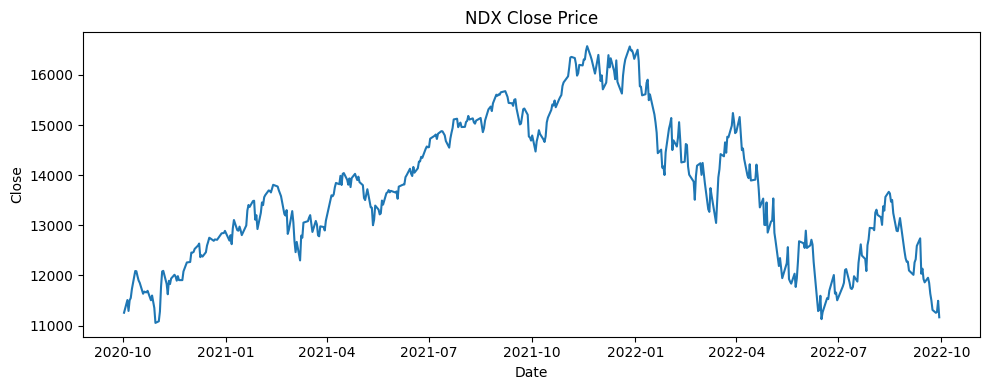

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(price_df['Date'], price_df['Close'])
ax.set_title('NDX Close Price')
ax.set_xlabel('Date')
ax.set_ylabel('Close')
plt.tight_layout()
plt.savefig('../results/close_price.png', dpi=120)
plt.show()


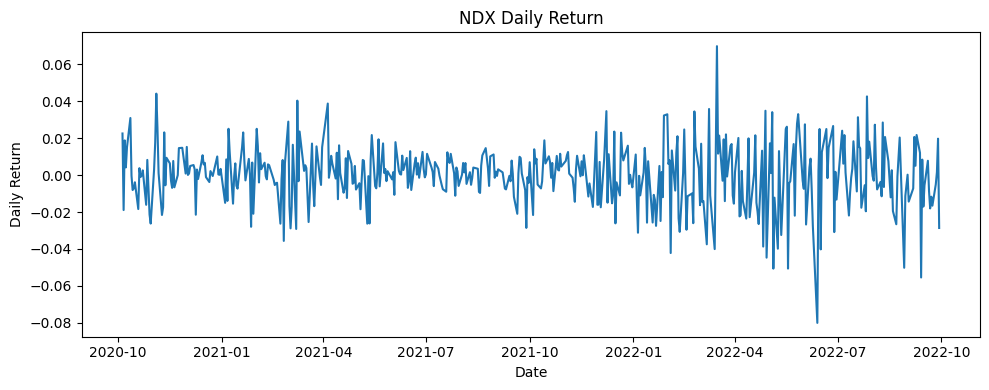

In [11]:
price_df_sorted = price_df.sort_values('Date')
daily_return = price_df_sorted['Close'].pct_change()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(price_df_sorted['Date'], daily_return)
ax.set_title('NDX Daily Return')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Return')
plt.tight_layout()
plt.savefig('../results/daily_return.png', dpi=120)
plt.show()


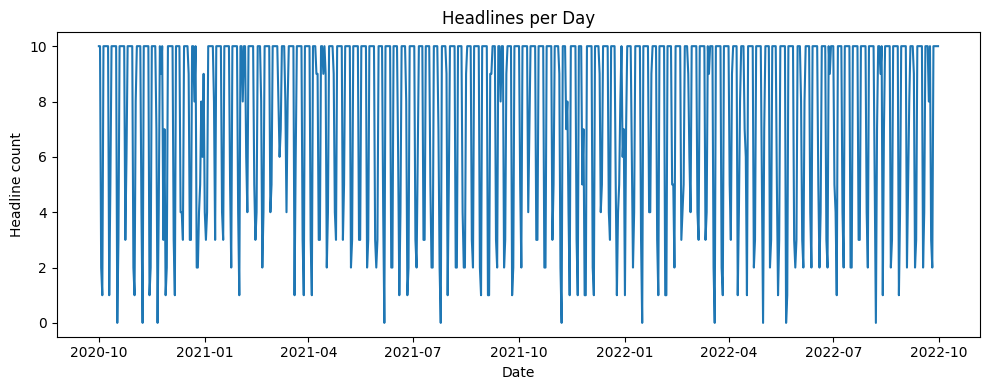

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(news_df['Date'], news_df['headline_count'])
ax.set_title('Headlines per Day')
ax.set_xlabel('Date')
ax.set_ylabel('Headline count')
plt.tight_layout()
plt.savefig('../results/headlines_per_day.png', dpi=120)
plt.show()


## 4. Summary of findings

- Price data: {rows} rows, {start} to {end}, no missing values, no duplicate dates.
- Price data quality issue: Open/High/Low/Close are identical and Volume is 0 for effectively all rows, so this isn't real OHLCV data and should be re-downloaded before modeling.
- News data: covers the same overall window, {news_rows} days with headlines, headline coverage is consistent day to day (see headlines-per-day plot).
- Price and news dates overlap almost completely, which matches the plan's approach of aligning news to trading days.
- News has ~1,700 '0' placeholder cells for days with fewer than 10 headlines (expected, handled by the existing filtering convention), plus a smaller number of genuinely repeated headline strings. One headline ("Recent commercial real estate transactions in New York.") repeats 50 times, which looks like a scraping artifact rather than real daily news.